In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 메타데이터 로드 및 수치화
df = pd.read_csv("metadata.csv")
test_df = df.copy()
test_df['Capacity'] = pd.to_numeric(test_df['Capacity'], errors='coerce')

# 2. 분석 대상 배터리 설정 (#33, #34, #36)
battery_ids = [33, 34, 36]
battery_names = [f'B{str(i).zfill(4)}' for i in battery_ids] # 'B0033', 'B0034', 'B0036'

# 3. 방전(discharge) 데이터만 필터링 (용량은 방전 시에만 측정됨)
discharge_df = test_df[(test_df['type'] == 'discharge') & (test_df['battery_id'].isin(battery_names))].copy()

# 사이클 순서대로 정렬 (중요)
discharge_df = discharge_df.sort_values(['battery_id', 'start_time'])

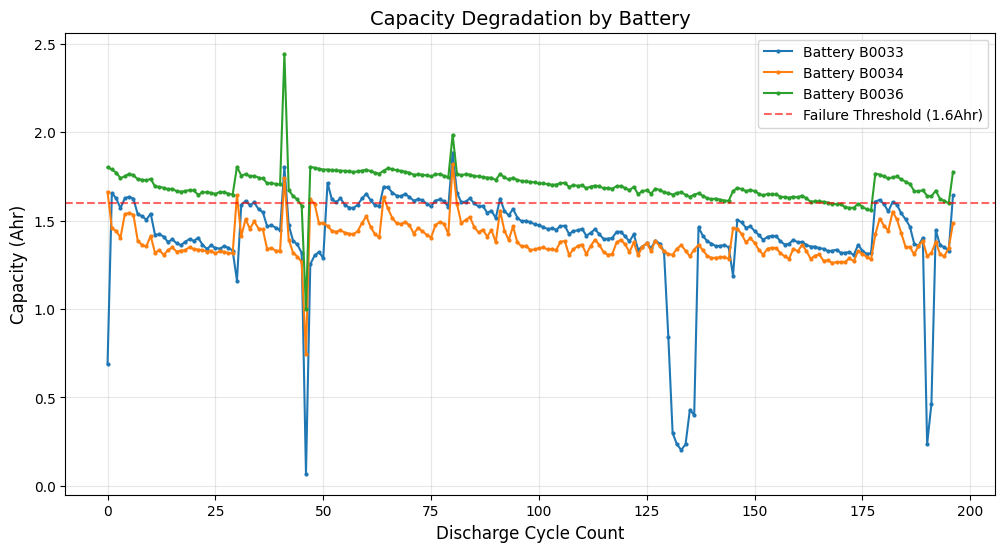

In [3]:
plt.figure(figsize=(12, 6))

for b_id in battery_names:
    subset = discharge_df[discharge_df['battery_id'] == b_id]
    # 각 배터리의 방전 이벤트 순서대로 인덱스 부여
    plt.plot(range(len(subset)), subset['Capacity'], label=f'Battery {b_id}', marker='.', markersize=4)

# 수명 종료 임계값 표시 (1.6Ahr)
plt.axhline(y=1.6, color='red', linestyle='--', alpha=0.6, label='Failure Threshold (1.6Ahr)')

plt.title('Capacity Degradation by Battery', fontsize=14)
plt.xlabel('Discharge Cycle Count', fontsize=12)
plt.ylabel('Capacity (Ahr)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

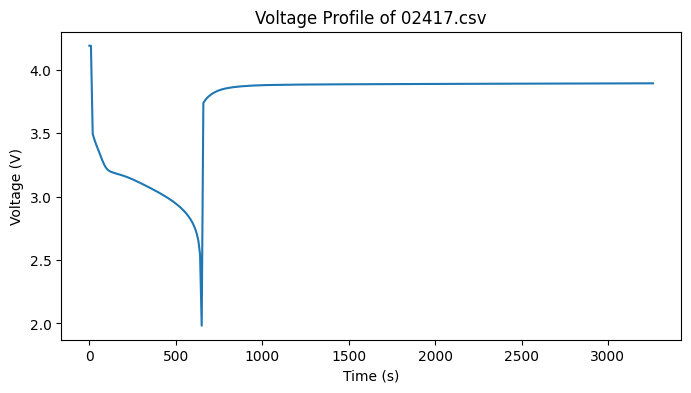

In [4]:
# 예: 첫 번째 방전 사이클의 세부 데이터 불러오기
first_filename = discharge_df.iloc[0]['filename']  # 예: '00123.csv'
data_path = os.path.join("cleaned_dataset", "data", first_filename)

detail_df = pd.read_csv(data_path)

# 세부 데이터 시각화 (전압 변화 예시)
plt.figure(figsize=(8, 4))
plt.plot(detail_df['Time'], detail_df['Voltage_measured'])
plt.title(f'Voltage Profile of {first_filename}')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.show()